In [1]:
IMAGE_PATH = "/home/ryam/Desktop/bioprint_vision_project/images"
CHESS_PATH = IMAGE_PATH + "/chessboard"

In [ ]:
"""Camera calibration using OpenCV with a chessboard pattern."""
import cv2
import numpy as np
import glob

# ── 1. Prepare object points for a 9x6 inner-corner grid ──────────────────────
# (9x6 = interior corners, not squares)
CHECKERBOARD = (9, 6)

objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
# Optional: set real square size, e.g. multiply by 25.0 for 25mm squares

objpoints = []  # 3D points in real world space
imgpoints = []  # 2D points in image plane

# ── 2. Load images and detect corners ─────────────────────────────────────────
images = glob.glob(CHESS_PATH + "/*.jpg")  # Adjust extension if needed

detected = 0
failed = 0
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    if ret:
        detected += 1
        objpoints.append(objp)

        # Refine corner locations to sub-pixel accuracy
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Optional: visualize detected corners
        cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
        cv2.imshow('Corners', img)
        cv2.waitKey(500)
    else:
        failed += 1
        print(f"Chessboard not detected in {fname}")

cv2.destroyAllWindows()

# ── 3. Calibrate ──────────────────────────────────────────────────────────────
ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

print("Camera Matrix:\n", camera_matrix)
print("\nDistortion Coefficients:\n", dist_coeffs)
print("\nReprojection Error:", ret)  # Should be < 1.0 (ideally < 0.5)

# ── 4. Save results ───────────────────────────────────────────────────────────
np.savez('/home/ryam/Desktop/bioprint_vision_project/calibration/calibration.npz',
         camera_matrix=camera_matrix,
         dist_coeffs=dist_coeffs)

# ── 5. Undistort a test image ─────────────────────────────────────────────────
img = cv2.imread(images[0])
h, w = img.shape[:2]

# Get optimal new camera matrix (crops black borders after undistortion)
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (w, h), 1, (w, h)
)

undistorted = cv2.undistort(img, camera_matrix, dist_coeffs, None, new_camera_matrix)

# Crop to valid region
x, y, w, h = roi
undistorted = undistorted[y:y+h, x:x+w]
cv2.imwrite('/home/ryam/Desktop/bioprint_vision_project/test_images/undistorted.jpg', undistorted)

Chessboard not detected in /home/ryam/Desktop/bioprint_vision_project/images/chessboard/chessboard7_20260305.jpg
Chessboard not detected in /home/ryam/Desktop/bioprint_vision_project/images/chessboard/chessboard1_20260305.jpg
Chessboard not detected in /home/ryam/Desktop/bioprint_vision_project/images/chessboard/chessboard9_20260305.jpg
Camera Matrix:
 [[1.54853709e+04 0.00000000e+00 1.75270100e+03]
 [0.00000000e+00 1.56040482e+04 1.82113308e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
 [[ 2.37909612e-01  2.19586134e+01  2.71216854e-02 -2.03949427e-02
  -1.64418218e+02]]

Reprojection Error: 1.1015012602093779


True

In [ ]:
# Debugging to see reprojection error per image
for i, (objp_i, imgp_i, rvec, tvec) in enumerate(zip(objpoints, imgpoints, rvecs, tvecs)):
    projected, _ = cv2.projectPoints(objp_i, rvec, tvec, camera_matrix, dist_coeffs)
    error = cv2.norm(imgp_i, projected, cv2.NORM_L2) / len(projected)
    print(f"Image {i+1}: {error:.4f} px")

Image 1: 0.1281 px
Image 2: 0.1841 px
Image 3: 0.1877 px
Image 4: 0.1477 px
Image 5: 0.1326 px
Image 6: 0.1355 px
Image 7: 0.1304 px
Image 8: 0.1396 px


In [ ]:
"""Compute homography from pixel coordinates to real-world mm using chessboard corners."""
import cv2
import numpy as np

# ── 1. Load your calibration results ──────────────────────────────────────────
data = np.load('/home/ryam/Desktop/bioprint_vision_project/calibration/calibration.npz')
camera_matrix = data['camera_matrix']
dist_coeffs   = data['dist_coeffs']

# ── 2. Define real-world 3D object points using actual square size ─────────────
CHECKERBOARD = (9, 6)
SQUARE_SIZE  = 20.4470000001  # mm

objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE  # now in mm

# ── 3. Detect corners in your reference image ──────────────────────────────────
img  = cv2.imread('/home/ryam/Desktop/bioprint_vision_project/images/chessboard/chessboard2_20260305.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

# ── 4. Undistort the corner points first ──────────────────────────────────────
corners_undistorted = cv2.undistortPoints(
    corners2, camera_matrix, dist_coeffs, P=camera_matrix
)

# ── 5. Compute homography (pixel → mm) ────────────────────────────────────────
# Use only the Z=0 plane (the board is flat)
objp_2d = objp[:, :2]  # drop Z column, just (X, Y) in mm

H, mask = cv2.findHomography(corners_undistorted, objp_2d)

print("Homography Matrix H:\n", H)

# ── 6. Convert a pixel coordinate to mm ───────────────────────────────────────
def pixel_to_mm(pixel_point, H, camera_matrix, dist_coeffs):
    """
    Convert a single (x, y) pixel coordinate to mm.
    pixel_point: (x, y) tuple
    """
    pt = np.array([[[pixel_point[0], pixel_point[1]]]], dtype=np.float32)

    # Undistort the point first
    pt_undistorted = cv2.undistortPoints(pt, camera_matrix, dist_coeffs, P=camera_matrix)

    # Apply homography
    pt_h = np.array([pt_undistorted[0][0][0],
                     pt_undistorted[0][0][1], 1.0])
    mm = H @ pt_h
    mm /= mm[2]  # normalise homogeneous coordinate

    return mm[0], mm[1]  # (X_mm, Y_mm)


# Example usage
px, py = 320, 240  # some pixel coordinate
x_mm, y_mm = pixel_to_mm((px, py), H, camera_matrix, dist_coeffs)
print(f"Pixel ({px}, {py})  →  ({x_mm:.3f} mm, {y_mm:.3f} mm)")

Homography Matrix H:
 [[-7.76452184e-02  3.20993745e-04  2.76756390e+02]
 [ 1.91184362e-04 -7.78687539e-02  1.33714537e+02]
 [ 2.02513610e-06  3.99597076e-06  1.00000000e+00]]
Pixel (320, 240)  →  (250.113 mm, 114.389 mm)


In [ ]:
"""Test homography accuracy by measuring distances between adjacent corners."""
import cv2
import numpy as np

# ── Configuration ──────────────────────────────────────────────────────────────
CHECKERBOARD = (9, 6)
SQUARE_SIZE  = 20.4470000001  # mm

# ── Load calibration ───────────────────────────────────────────────────────────
data          = np.load('/home/ryam/Desktop/bioprint_vision_project/calibration/calibration.npz')
camera_matrix = data['camera_matrix']
dist_coeffs   = data['dist_coeffs']

# ── Build ground truth object points (mm) ─────────────────────────────────────
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

# ── Detect corners in test image ───────────────────────────────────────────────
img  = cv2.imread('/home/ryam/Desktop/bioprint_vision_project/images/chessboard/chessboard4_20260305.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
assert ret, "Chessboard corners not detected — check image path or grid size"

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
corners2  = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

# ── Compute homography ─────────────────────────────────────────────────────────
corners_undistorted = cv2.undistortPoints(
    corners2, camera_matrix, dist_coeffs, P=camera_matrix
)
H, _ = cv2.findHomography(corners_undistorted, objp[:, :2])

# ── Helper ─────────────────────────────────────────────────────────────────────
def pixel_to_mm(pixel_point, H, camera_matrix, dist_coeffs):
    pt = np.array([[[pixel_point[0], pixel_point[1]]]], dtype=np.float32)
    pt_ud = cv2.undistortPoints(pt, camera_matrix, dist_coeffs, P=camera_matrix)
    pt_h  = np.array([pt_ud[0][0][0], pt_ud[0][0][1], 1.0])
    mm    = H @ pt_h
    mm   /= mm[2]
    return mm[0], mm[1]

# ── Test: measure side lengths of squares and compare to ground truth ──────────
# Adjacent horizontal corner pairs: corner i and i+1 (same row, next column)
# Adjacent vertical corner pairs:   corner i and i+9 (next row, same column)

TOLERANCE_MM = 0.5
all_passed   = True

h_errors = []
v_errors = []

print("Horizontal squares (along columns):")
print(f"  {'Corners':<15} {'Measured (mm)':<20} {'Expected (mm)':<20} {'Error (mm)':<15} Status")
print("  " + "-" * 75)

for row in range(CHECKERBOARD[1]):          # 0..5
    for col in range(CHECKERBOARD[0] - 1):  # 0..7  (pairs within a row)
        idx_a = row * CHECKERBOARD[0] + col
        idx_b = idx_a + 1

        ax, ay = pixel_to_mm(corners2[idx_a][0], H, camera_matrix, dist_coeffs)
        bx, by = pixel_to_mm(corners2[idx_b][0], H, camera_matrix, dist_coeffs)

        measured = np.sqrt((bx - ax)**2 + (by - ay)**2)
        error    = abs(measured - SQUARE_SIZE)
        passed   = error < TOLERANCE_MM
        if not passed:
            all_passed = False
        h_errors.append(error)

        print(f"  {idx_a}-{idx_b:<12} {measured:<20.4f} {SQUARE_SIZE:<20.7f} {error:<15.4f} {'✓' if passed else '✗ FAIL'}")

print("\nVertical squares (along rows):")
print(f"  {'Corners':<15} {'Measured (mm)':<20} {'Expected (mm)':<20} {'Error (mm)':<15} Status")
print("  " + "-" * 75)

for row in range(CHECKERBOARD[1] - 1):     # 0..4
    for col in range(CHECKERBOARD[0]):      # 0..8
        idx_a = row * CHECKERBOARD[0] + col
        idx_b = idx_a + CHECKERBOARD[0]

        ax, ay = pixel_to_mm(corners2[idx_a][0], H, camera_matrix, dist_coeffs)
        bx, by = pixel_to_mm(corners2[idx_b][0], H, camera_matrix, dist_coeffs)

        measured = np.sqrt((bx - ax)**2 + (by - ay)**2)
        error    = abs(measured - SQUARE_SIZE)
        passed   = error < TOLERANCE_MM
        if not passed:
            all_passed = False
        v_errors.append(error)

        print(f"  {idx_a}-{idx_b:<12} {measured:<20.4f} {SQUARE_SIZE:<20.7f} {error:<15.4f} {'✓' if passed else '✗ FAIL'}")

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 77)
print(f"  Horizontal — mean error: {np.mean(h_errors):.4f} mm  |  max error: {np.max(h_errors):.4f} mm")
print(f"  Vertical   — mean error: {np.mean(v_errors):.4f} mm  |  max error: {np.max(v_errors):.4f} mm")
print(f"  Overall    — mean error: {np.mean(h_errors + v_errors):.4f} mm  |  max error: {np.max(h_errors + v_errors):.4f} mm")
print(f"\n  All tests passed: {all_passed}")
print("=" * 77)

Horizontal squares (along columns):
  Corners         Measured (mm)        Expected (mm)        Error (mm)      Status
  ---------------------------------------------------------------------------
  0-1            20.5107              20.4470000           0.0637          ✓
  1-2            20.3871              20.4470000           0.0599          ✓
  2-3            20.4821              20.4470000           0.0351          ✓
  3-4            20.3911              20.4470000           0.0559          ✓
  4-5            20.4431              20.4470000           0.0039          ✓
  5-6            20.4863              20.4470000           0.0393          ✓
  6-7            20.4637              20.4470000           0.0167          ✓
  7-8            20.5117              20.4470000           0.0647          ✓
  9-10           20.4836              20.4470000           0.0366          ✓
  10-11           20.3616              20.4470000           0.0854          ✓
  11-12           20.4778       

In [ ]:
# TEST_IMAGE = "images/green_square/clear_square_green1.jpg"
TEST_IMAGE = "images\\better_square_photos\\light_2_20260327.jpg"

ValueError: input operand has more dimensions than allowed by the axis remapping

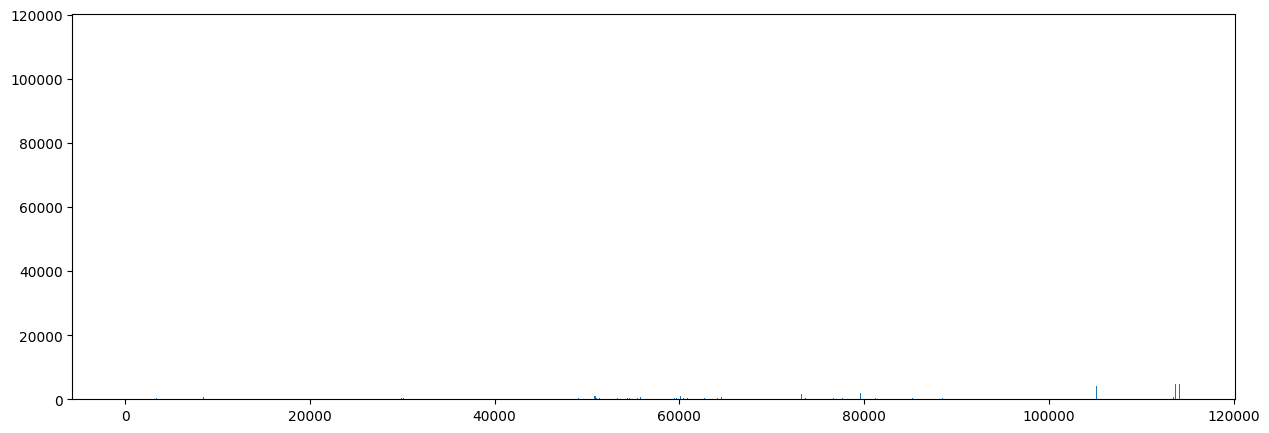

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(TEST_IMAGE)

# Remove pure white pixels
filtered = img[~np.all(img == [255, 255, 255], axis=2)]

colors = ('b', 'g', 'r')

for i, color in enumerate(colors):
    hist, bins = np.histogram(filtered[:, i], bins=256, range=(0,256))

    # maximum pixel value (most frequent)
    max_val = np.argmax(hist)
    print(f"{color.upper()} channel maximum: pixel value = {max_val}, count = {hist[max_val]}")

    plt.plot(hist, color=color)

plt.xlim([0,256])
plt.title("RGB Histogram (white pixels removed)")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")
plt.show()

In [50]:
import cv2
import numpy as np

# Load image
image = cv2.imread(TEST_IMAGE)

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Lower and upper bounds for green in HSV
lower_green = np.array([40, 65, 0])   # H, S, V
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)

# Remove small noise
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
# Close small holes
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Initialize GrabCut with the mask
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)
mask2 = np.where(mask==255, 1, 0).astype('uint8')

cv2.grabCut(image, mask2, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
final_mask = np.where((mask2==1) | (mask2==3), 255, 0).astype('uint8')

cv2.imwrite("test_images/green_object_mask.png", final_mask)

True

In [4]:
import cv2
import numpy as np

# Load image
image = cv2.imread(TEST_IMAGE)

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Lower and upper bounds for green in HSV
lower_green = np.array([65, 64, 0])   # H, S, V
upper_green = np.array([85, 255, 235])

mask = cv2.inRange(hsv, lower_green, upper_green)

# Remove small noise
kernel = np.ones((11, 11), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
# Close small holes
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Initialize GrabCut with the mask
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)
mask2 = np.where(mask==255, 1, 0).astype('uint8')

cv2.grabCut(image, mask2, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
final_mask = np.where((mask2==1) | (mask2==3), 255, 0).astype('uint8')

cv2.imwrite("test_images/green_object_mask.png", final_mask)

# Find contours in the final mask
contours, _ = cv2.findContours(final_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a copy of the original image
contour_image = image.copy()
cv2.drawContours(contour_image, contours, -1, (0, 0, 255), 2)
cv2.imwrite("test_images/green_object_contours.png", contour_image)

True

In [59]:
# Getting the perfect HSV values
 
import pyautogui
import cv2
import numpy as np
import time

def get_hsv_at_cursor():
    while True:
        # Get current mouse position
        x, y = pyautogui.position()
        
        # Take a screenshot
        screenshot = pyautogui.screenshot()
        
        # Convert the screenshot to a numpy array (OpenCV uses BGR)
        img = np.array(screenshot)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        
        # Get BGR value at cursor
        b, g, r = img[y, x]
        
        # Convert BGR to HSV
        hsv = cv2.cvtColor(np.uint8([[[b, g, r]]]), cv2.COLOR_BGR2HSV)[0][0]
        
        print(f"Cursor at ({x}, {y}) - HSV: {hsv}")
        
        time.sleep(0.5)  # update every 0.5 seconds

if __name__ == "__main__":
    print("Press Ctrl+C to stop.")
    get_hsv_at_cursor()

Press Ctrl+C to stop.
Cursor at (239, 152) - HSV: [120   4  67]
Cursor at (1461, 502) - HSV: [ 76 179 216]
Cursor at (1209, 432) - HSV: [ 74 125 182]
Cursor at (1210, 434) - HSV: [ 75 206 109]
Cursor at (1293, 493) - HSV: [ 76 191 175]
Cursor at (1315, 491) - HSV: [ 76 183 184]
Cursor at (1364, 538) - HSV: [ 73 107 181]
Cursor at (1314, 319) - HSV: [ 63  12 255]
Cursor at (1279, 305) - HSV: [ 72  89 190]
Cursor at (1236, 423) - HSV: [ 70  15 255]
Cursor at (1183, 414) - HSV: [ 74 135 160]
Cursor at (1200, 422) - HSV: [ 72  32 234]
Cursor at (1206, 404) - HSV: [ 68  15 253]
Cursor at (1206, 401) - HSV: [ 69  14 255]
Cursor at (1206, 401) - HSV: [ 69  14 255]
Cursor at (1206, 401) - HSV: [ 69  14 255]
Cursor at (1195, 377) - HSV: [ 67  17 249]
Cursor at (1194, 381) - HSV: [ 66  14 255]
Cursor at (1203, 403) - HSV: [ 64  14 255]
Cursor at (1209, 417) - HSV: [ 63  12 255]
Cursor at (681, 620) - HSV: [105  19  27]
Cursor at (677, 645) - HSV: [105  26  20]
Cursor at (677, 650) - HSV: [105  2

KeyboardInterrupt: 